# Лабораторная работа №2

Задания по изменению размера изображения и преобразованиям яркости:

1. Увеличение изображения методом ближайшего соседа и билинейной интерполяцией.
2. Сжатие изображения выборкой пикселей и усреднением.
3. Нормализованная линейная трансформация гистограммы.
4. Гамма-коррекция.
5. Эквализация гистограммы.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.grid"] = False


Размер исходного изображения: 1280 x 720
Размер фрагмента для resize: 400 x 400


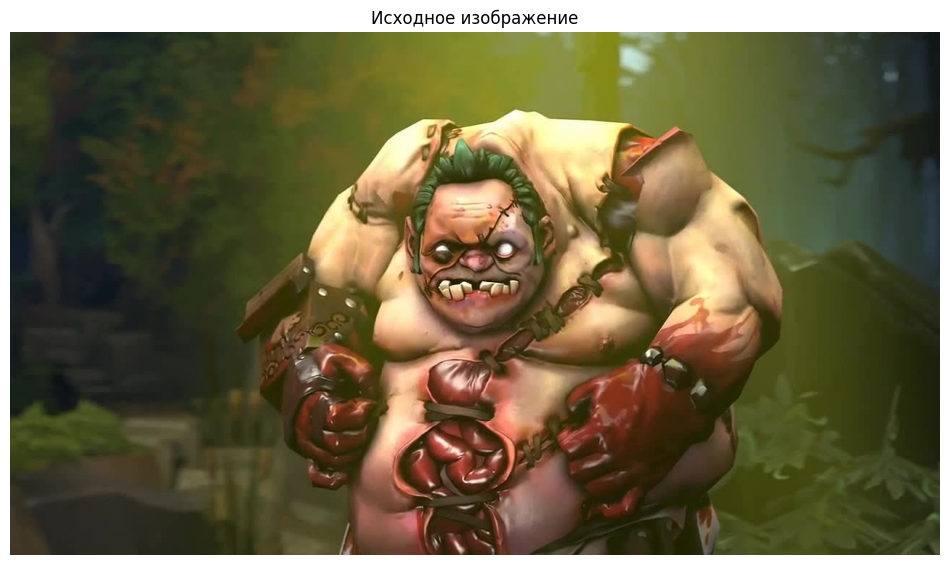

In [2]:
image_path = Path("image.jpg")
img_bgr = cv2.imread(str(image_path))

if img_bgr is None:
    raise FileNotFoundError("Файл image.jpg должен лежать рядом с ноутбуком.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Для увеличения используем фрагмент изображения, чтобы ручная интерполяция
# выполнялась быстро и результат было удобно рассматривать.
demo_rgb = img_rgb[120:520, 320:720]

print(f"Размер исходного изображения: {img_rgb.shape[1]} x {img_rgb.shape[0]}")
print(f"Размер фрагмента для resize: {demo_rgb.shape[1]} x {demo_rgb.shape[0]}")

plt.imshow(img_rgb)
plt.title("Исходное изображение")
plt.axis("off")
plt.show()


In [3]:
def to_uint8(image):
    return np.clip(np.rint(image), 0, 255).astype(np.uint8)


def plot_image_grid(images, titles, cols=3, figsize=(14, 8), cmap=None):
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for ax, image, title in zip(axes, images, titles):
        if image.ndim == 2:
            ax.imshow(image, cmap=cmap or "gray", vmin=0, vmax=255)
        else:
            ax.imshow(image)
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[len(images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def plot_gray_and_hist(before, after, before_title, after_title):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    axes[0, 0].imshow(before, cmap="gray", vmin=0, vmax=255)
    axes[0, 0].set_title(before_title)
    axes[0, 0].axis("off")

    axes[0, 1].imshow(after, cmap="gray", vmin=0, vmax=255)
    axes[0, 1].set_title(after_title)
    axes[0, 1].axis("off")

    axes[1, 0].hist(before.ravel(), bins=256, range=(0, 255), color="tab:blue")
    axes[1, 0].set_title("Гистограмма до")
    axes[1, 0].set_xlim(0, 255)

    axes[1, 1].hist(after.ravel(), bins=256, range=(0, 255), color="tab:green")
    axes[1, 1].set_title("Гистограмма после")
    axes[1, 1].set_xlim(0, 255)

    plt.tight_layout()
    plt.show()


## Задание 1. Изменение размера изображения

Реализованы две функции увеличения изображения при `size_factor > 1`:

- `resize_nn(img, size_factor)` — метод ближайшего соседа.
- `resize_bilinear(img, size_factor)` — билинейная интерполяция.


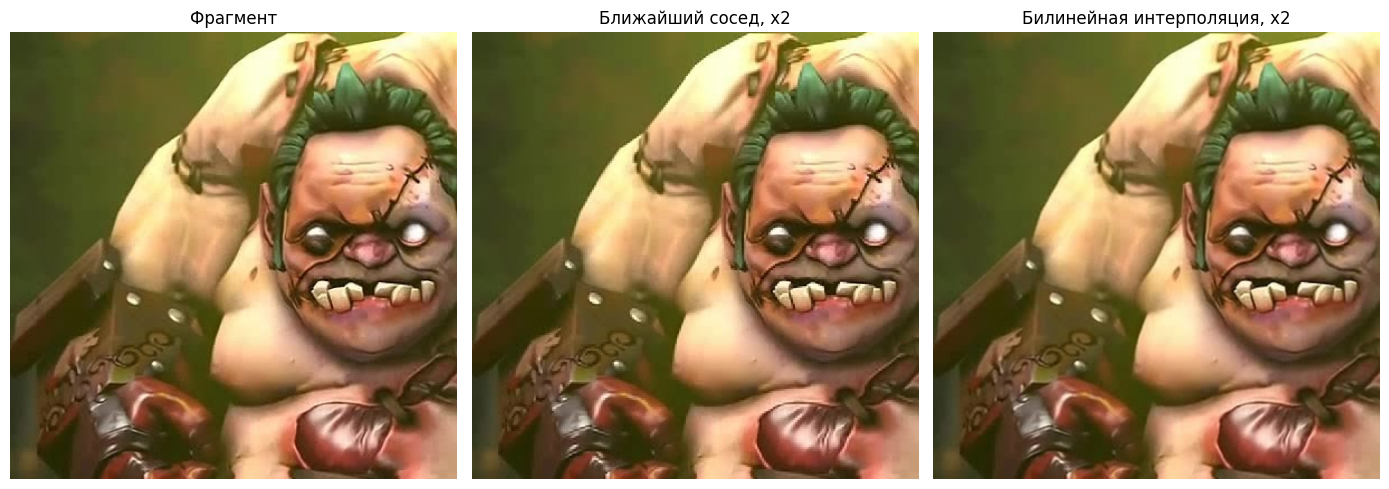

In [4]:
def resize_nn(img, size_factor):
    if size_factor <= 1:
        raise ValueError("size_factor должен быть больше 1")

    h, w = img.shape[:2]
    new_h = max(1, int(round(h * size_factor)))
    new_w = max(1, int(round(w * size_factor)))

    y_idx = np.rint(np.arange(new_h) / size_factor).astype(int)
    x_idx = np.rint(np.arange(new_w) / size_factor).astype(int)
    y_idx = np.clip(y_idx, 0, h - 1)
    x_idx = np.clip(x_idx, 0, w - 1)

    return img[y_idx[:, None], x_idx[None, :]]


def resize_bilinear(img, size_factor):
    if size_factor <= 1:
        raise ValueError("size_factor должен быть больше 1")

    h, w = img.shape[:2]
    new_h = max(1, int(round(h * size_factor)))
    new_w = max(1, int(round(w * size_factor)))

    gray_input = img.ndim == 2
    src = img[..., None].astype(np.float32) if gray_input else img.astype(np.float32)

    y = np.arange(new_h, dtype=np.float32) / size_factor
    x = np.arange(new_w, dtype=np.float32) / size_factor

    y0 = np.floor(y).astype(int)
    x0 = np.floor(x).astype(int)
    y1 = np.clip(y0 + 1, 0, h - 1)
    x1 = np.clip(x0 + 1, 0, w - 1)

    y0 = np.clip(y0, 0, h - 1)
    x0 = np.clip(x0, 0, w - 1)

    wy = (y - y0)[:, None, None]
    wx = (x - x0)[None, :, None]

    top_left = src[y0[:, None], x0[None, :]]
    top_right = src[y0[:, None], x1[None, :]]
    bottom_left = src[y1[:, None], x0[None, :]]
    bottom_right = src[y1[:, None], x1[None, :]]

    top = top_left * (1 - wx) + top_right * wx
    bottom = bottom_left * (1 - wx) + bottom_right * wx
    result = top * (1 - wy) + bottom * wy
    result = to_uint8(result)

    return result[..., 0] if gray_input else result


nn_2x = resize_nn(demo_rgb, 2.0)
bilinear_2x = resize_bilinear(demo_rgb, 2.0)

plot_image_grid(
    [demo_rgb, nn_2x, bilinear_2x],
    ["Фрагмент", "Ближайший сосед, x2", "Билинейная интерполяция, x2"],
    cols=3,
)


## Задание 2. Сжатие изображения

`downsample_1(img, size_factor)` сжимает изображение выборкой ближайших пикселей.  
`downsample_2(img, size_factor)` сжимает изображение усреднением значений внутри области исходного изображения.


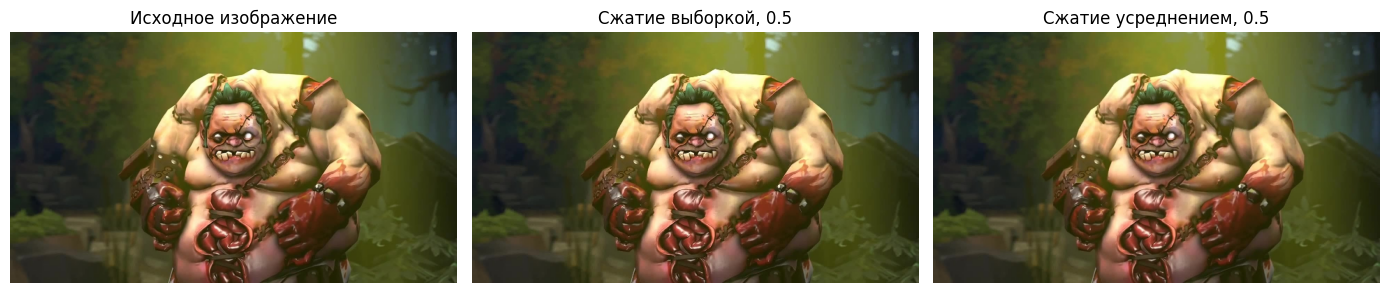

In [5]:
def downsample_1(img, size_factor):
    if not 0 < size_factor < 1:
        raise ValueError("size_factor должен быть в диапазоне (0, 1)")

    h, w = img.shape[:2]
    new_h = max(1, int(round(h * size_factor)))
    new_w = max(1, int(round(w * size_factor)))

    y_idx = np.floor(np.arange(new_h) / size_factor).astype(int)
    x_idx = np.floor(np.arange(new_w) / size_factor).astype(int)
    y_idx = np.clip(y_idx, 0, h - 1)
    x_idx = np.clip(x_idx, 0, w - 1)

    return img[y_idx[:, None], x_idx[None, :]]


def downsample_2(img, size_factor):
    if not 0 < size_factor < 1:
        raise ValueError("size_factor должен быть в диапазоне (0, 1)")

    h, w = img.shape[:2]
    new_h = max(1, int(round(h * size_factor)))
    new_w = max(1, int(round(w * size_factor)))

    gray_input = img.ndim == 2
    src = img[..., None].astype(np.float64) if gray_input else img.astype(np.float64)

    y0 = np.floor(np.arange(new_h) / size_factor).astype(int)
    x0 = np.floor(np.arange(new_w) / size_factor).astype(int)
    y1 = np.ceil((np.arange(new_h) + 1) / size_factor).astype(int)
    x1 = np.ceil((np.arange(new_w) + 1) / size_factor).astype(int)

    y0 = np.clip(y0, 0, h - 1)
    x0 = np.clip(x0, 0, w - 1)
    y1 = np.clip(y1, y0 + 1, h)
    x1 = np.clip(x1, x0 + 1, w)

    integral = np.pad(src.cumsum(axis=0).cumsum(axis=1), ((1, 0), (1, 0), (0, 0)))
    region_sum = (
        integral[y1[:, None], x1[None, :]]
        - integral[y0[:, None], x1[None, :]]
        - integral[y1[:, None], x0[None, :]]
        + integral[y0[:, None], x0[None, :]]
    )
    area = (y1 - y0)[:, None] * (x1 - x0)[None, :]
    result = region_sum / area[..., None]
    result = to_uint8(result)

    return result[..., 0] if gray_input else result


sampled_half = downsample_1(img_rgb, 0.5)
averaged_half = downsample_2(img_rgb, 0.5)

plot_image_grid(
    [img_rgb, sampled_half, averaged_half],
    [
        "Исходное изображение",
        "Сжатие выборкой, 0.5",
        "Сжатие усреднением, 0.5",
    ],
    cols=3,
)


## Задание 3. Изменение яркости

Функция `linear_hist_transform(img, persent=0.05)` выполняет нормализованную линейную трансформацию гистограммы для монохромного изображения. Нижний и верхний хвосты гистограммы отсекаются симметрично, после чего значения растягиваются на диапазон `[0, 255]`.


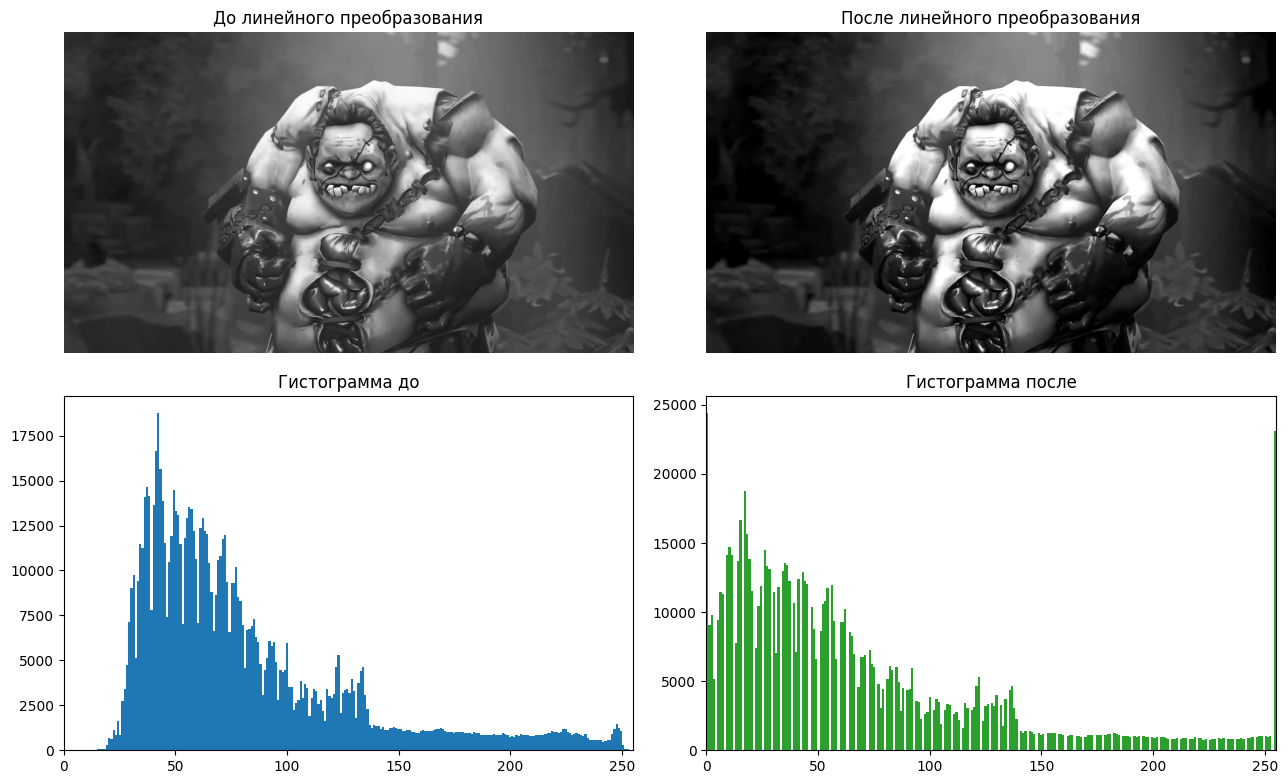

In [6]:
def linear_hist_transform(img, persent=0.05):
    if img.ndim != 2:
        raise ValueError("Функция ожидает монохромное изображение")
    if not 0 <= persent < 1:
        raise ValueError("persent должен быть в диапазоне [0, 1)")

    image = img.astype(np.float32)
    tail = persent * 100 / 2
    low, high = np.percentile(image, [tail, 100 - tail])

    if high <= low:
        return np.zeros_like(img, dtype=np.uint8)

    transformed = (image - low) * 255 / (high - low)
    return np.clip(transformed, 0, 255).astype(np.uint8)


linear_gray = linear_hist_transform(img_gray, persent=0.05)

plot_gray_and_hist(
    img_gray,
    linear_gray,
    "До линейного преобразования",
    "После линейного преобразования",
)


## Задание 4. Гамма-коррекция

`gamma_transform(img, gamma)` сначала нормализует яркости в `[0, 1]`, затем применяет степенное преобразование.


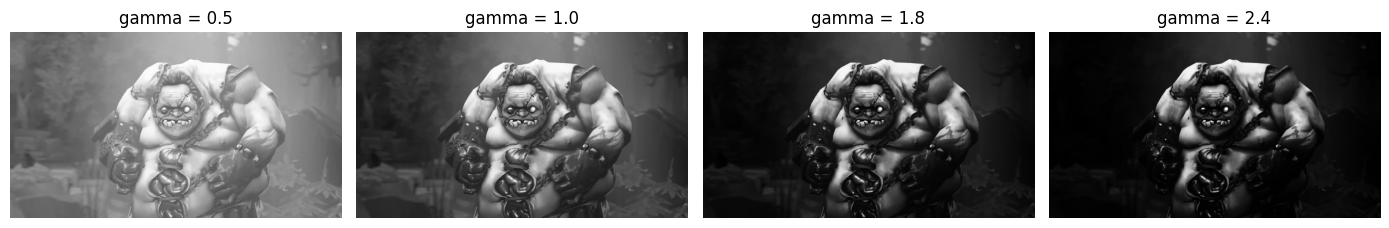

In [7]:
def gamma_transform(img, gamma):
    if img.ndim != 2:
        raise ValueError("Функция ожидает монохромное изображение")
    if gamma <= 0:
        raise ValueError("gamma должен быть положительным")

    normalized = img.astype(np.float32) / 255.0
    transformed = normalized ** gamma
    return np.clip(transformed * 255, 0, 255).astype(np.uint8)


gammas = [0.5, 1.0, 1.8, 2.4]
gamma_images = [gamma_transform(img_gray, gamma) for gamma in gammas]

plot_image_grid(
    gamma_images,
    [f"gamma = {gamma}" for gamma in gammas],
    cols=4,
    figsize=(14, 4),
    cmap="gray",
)


## Задание 5. Эквализация гистограммы

`hist_eq(img)` строит гистограмму, вычисляет накопленную функцию распределения и по ней формирует таблицу замены яркостей.


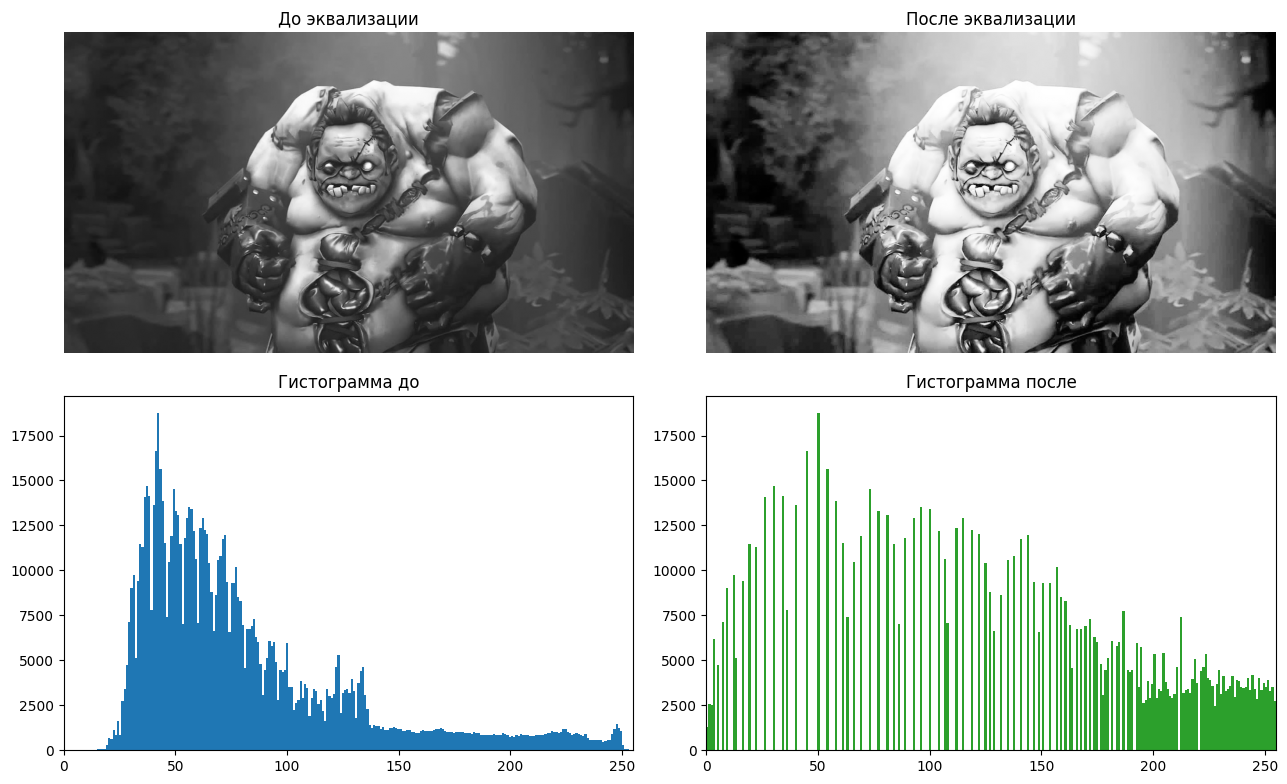

In [8]:
def hist_eq(img):
    if img.ndim != 2:
        raise ValueError("Функция ожидает монохромное изображение")

    hist = np.bincount(img.ravel(), minlength=256).astype(np.float64)
    cdf = hist.cumsum()
    nonzero = cdf > 0

    if not np.any(nonzero):
        return img.copy()

    cdf_min = cdf[nonzero][0]
    denom = img.size - cdf_min

    if denom == 0:
        return img.copy()

    lut = np.round((cdf - cdf_min) / denom * 255)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    return lut[img]


equalized_gray = hist_eq(img_gray)

plot_gray_and_hist(
    img_gray,
    equalized_gray,
    "До эквализации",
    "После эквализации",
)


## Вывод

В работе реализованы базовые операции ресайза, сжатия и преобразования яркости без использования готовых функций OpenCV для этих алгоритмов. На изображениях и гистограммах видно, как интерполяция влияет на качество масштабирования, а линейная трансформация, гамма-коррекция и эквализация меняют распределение яркостей.
